In [59]:
using DataFrames, CSV, Plots
include("/Users/johnbuckner/.julia/dev/UniversalDiffEq.jl/src/UniversalDiffEq.jl")


Main.UniversalDiffEq

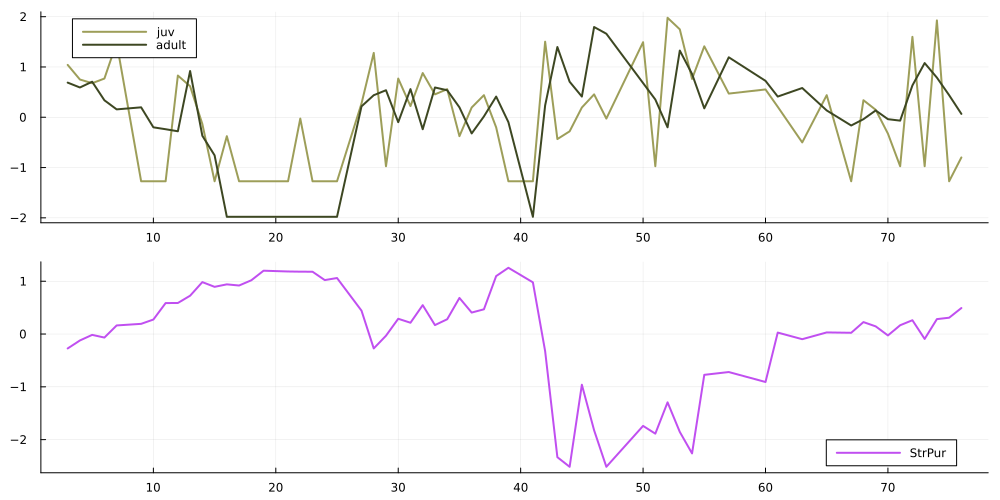

In [60]:
site = 2
dat = CSV.read("../data/processed_time_series.csv", DataFrame)[:,2:end]
dat = sort(dat,:PERIOD)

dat_states = dat[dat.SITE .== site,[:PERIOD,:MacJuv,:MacPyr]]
training = dat_states

X = dat[dat.SITE .== site,[:PERIOD,:StrPur]]



p1 = Plots.plot(training.PERIOD, training.MacJuv, label = "juv", width = 2, color = "#9d9e59" )
Plots.plot!(training.PERIOD, training.MacPyr, label = "adult", width = 2, color = "#3d4722")
#Plots.plot!(testing.PERIOD, testing.MacJuv, label = "juv testing", width = 1.5, linestyle = :dash, color = "#9d9e59")
#Plots.plot!(testing.PERIOD, testing.MacPyr, label = "adult training", width = 1.5,linestyle = :dash, color = "#3d4722")
p2 = Plots.plot(X.PERIOD, X.StrPur, label = "StrPur", width = 2, color = "#c04ff0" )
plot(p1,p2, layout = (2,1), size = (1000,500))

In [61]:
X[1:2,:]

Row,PERIOD,StrPur
,Int64,Float64
1,3,-0.273192
2,4,-0.12171


In [62]:
covars = []

NN, NNparameters = UniversalDiffEq.SimpleNeuralNetwork(2+length(covars),2, hidden = 10, seed = 5491)

function dudt(u,X,p,t,covars)
    return NN(vcat(u,X[covars]), p.NN) # index 3 is pycnopodia  ,X[1:2]
end

init_parameters = (NN = NNparameters, )

NODE = UniversalDiffEq.CustomDerivatives(training,X,(u,X,p,t) -> dudt(u,X,p,t,covars),
                                            init_parameters;time_column_name = "PERIOD")

UniversalDiffEq.train!(NODE, loss_function = "spline gradient matching", 
        regularization_weight = 100, optim_options = (maxiter = 500, step_size = 0.025), 
        loss_options = (σ = 0.05, τ = 0.5, T = 2*size(training)[1]))
nothing

126
52875.959 50825.582 48875.23 47017.511 45240.641 43533.538 41888.264 40299.98 38766.079 37285.403 35857.589 34482.467 33159.647 31888.369 30667.505 29495.607 28370.946 27291.615 26255.682 25261.313 24306.817 23390.652 22511.425 21667.884 20858.881 20083.329 19340.168 18628.353 17946.82 17294.468 16670.148 16072.683 15500.883 14953.573 14429.638 13928.06 13447.933 12988.437 12548.814 12128.336 11726.294 11341.975 10974.667 10623.675 10288.328 9967.989 9662.059 9369.974 9091.187 8825.16 8571.361 8329.262 8098.353 7878.143 7668.17 7467.994 7277.194 7095.364 6922.107 6757.045 6599.819 6450.09 6307.533 6171.828 6042.652 5919.687 5802.627 5691.184 5585.088 5484.081 5387.912 5296.338 5209.129 5126.072 5046.969 4971.627 4899.862 4831.496 4766.367 4704.32 4645.211 4588.9 4535.256 4484.153 4435.477 4389.119 4344.974 4302.941 4262.924 4224.832 4188.578 4154.077 4121.247 4090.009 4060.288 4032.012 4005.109 3979.512 3955.158 3931.983 3909.93 3888.943 3868.968 3849.954 3831.853 3814.619 3798.208

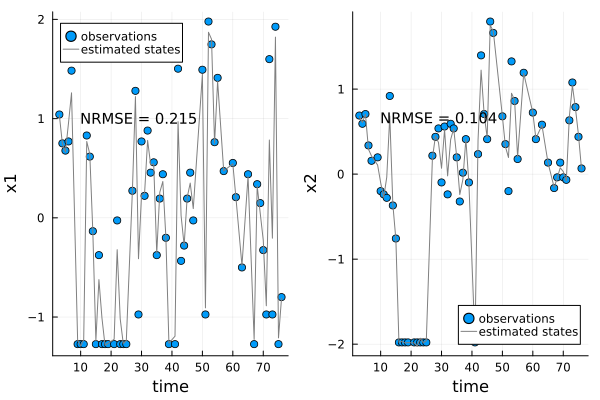

In [63]:
UniversalDiffEq.plot_state_estimates(NODE)

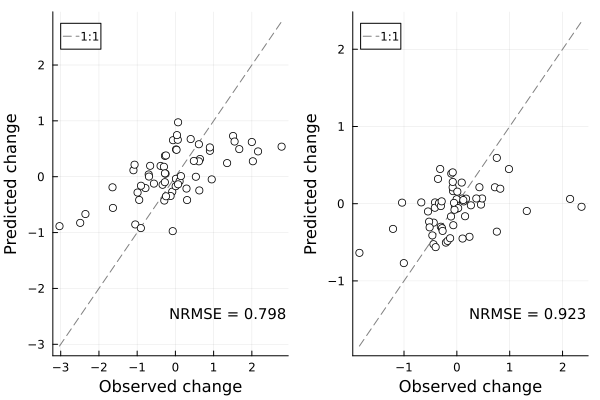

In [64]:
UniversalDiffEq.plot_predictions(NODE)

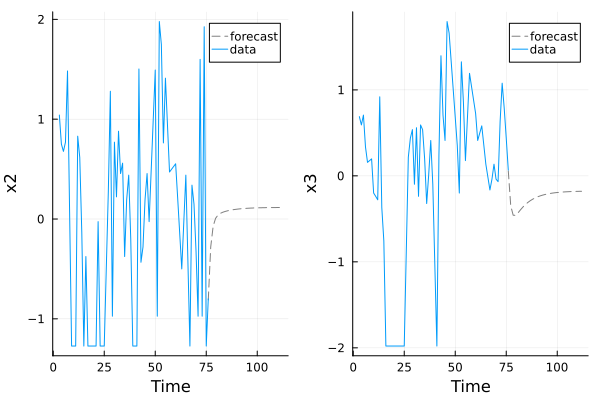

In [65]:
plt,(p1,p2)=UniversalDiffEq.plot_forecast(NODE, 30)
plt

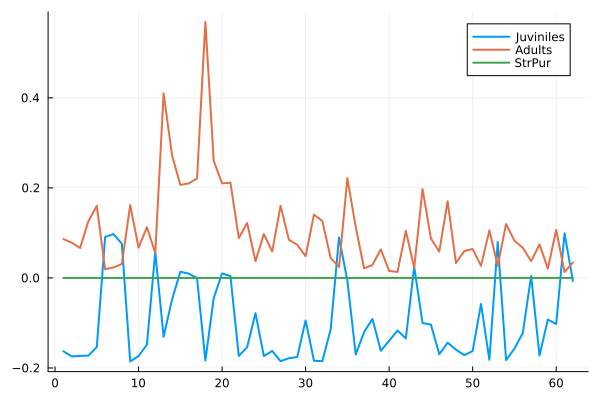

In [66]:

using ForwardDiff


function transform(u,mean,scale)
    y = scale.*exp.(u).+mean
    return y
end


function percap_growth(y,mean,scale)
    u = log.((y.-mean)./scale)
    X = u[3:end]; u = u[1:2]
    dydu = scale[1:2].*exp.(u)
    dudt = rhs(u,X,0.0)
    return dydu.*dudt./y[1:2]
end 


function percap_growth_jacobian(y,mean,scale)
    f = y ->  percap_growth(y,mean,scale)
    return ForwardDiff.jacobian(f, y)
end 


function get_scaling_factors(site)
    scaling_factors  = CSV.read("../data/scaling_factors.csv", DataFrame)[:,2:end]
    scaling_factors = scaling_factors[scaling_factors.SITE.==site,:]
    Xinds = [4,6,1]
    mean = scaling_factors.mean[Xinds]
    scale = scaling_factors.sd[Xinds]
    return scale, mean
end

rhs = UniversalDiffEq.get_right_hand_side(NODE)

scale, means = get_scaling_factors(4)
obs = size(NODE.parameters.uhat)[2]
effects_juv = zeros(obs,3)
effects_adults = zeros(obs,3)
for i in 1:size(NODE.parameters.uhat)[2]
    u = vcat(NODE.parameters.uhat[:,i],Vector(NODE.X[i,2:end]))
    y = transform(u,means,scale)
    effects = percap_growth_jacobian(y,means,scale)
    effects_juv[i,:] = effects[1,:]
    effects_adults[i,:] = effects[2,:]
end 

Plots.plot(effects_juv[:,1], width = 2, label = "Juviniles")
Plots.plot!(effects_juv[:,2], width = 2, label = "Adults")
Plots.plot!(effects_juv[:,3], width = 2, label = "StrPur")


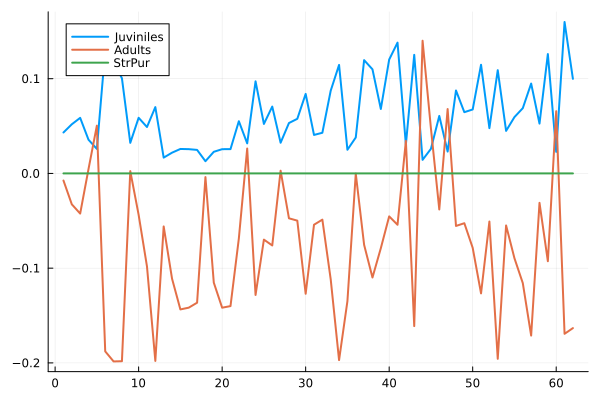

In [67]:
Plots.plot(effects_adults[:,1], width = 2, label = "Juviniles")
Plots.plot!(effects_adults[:,2], width = 2, label = "Adults")
Plots.plot!(effects_adults[:,3], width = 2, label = "StrPur")